#  Police Traffic Stops — Comprehensive Analysis
### Exploratory Data Analysis & Statistical Insights

## 1. Setup & Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


In [64]:
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e"})
ACCENT = ["#7b68ee", "#00d4aa", "#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff"]

## 2. Load Data

In [65]:
df = pd.read_csv(r"D:\coding\jupyter\just just\jupytr\proper projects 2\police.csv")
print(f"Shape: {df.shape}")

Shape: (91741, 15)


In [34]:
df.head()

,stop_date,stop_time,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91741 entries, 0 to 91740
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           91741 non-null  object 
 1   stop_time           91741 non-null  object 
 2   county_name         0 non-null      float64
 3   driver_gender       86406 non-null  object 
 4   driver_age_raw      86414 non-null  float64
 5   driver_age          86120 non-null  float64
 6   driver_race         86408 non-null  object 
 7   violation_raw       86408 non-null  object 
 8   violation           86408 non-null  object 
 9   search_conducted    91741 non-null  bool   
 10  search_type         3196 non-null   object 
 11  stop_outcome        86408 non-null  object 
 12  is_arrested         86408 non-null  object 
 13  stop_duration       86408 non-null  object 
 14  drugs_related_stop  91741 non-null  bool   
dtypes: bool(2), float64(3), object(10)
memory usage: 9.3+

In [36]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Count": missing, "%": missing_pct}).query("Count > 0").sort_values("%", ascending=False)

,Count,%
county_name,91741,100.00
search_type,88545,96.52
driver_age,5621,6.13
driver_gender,5335,5.82
driver_age_raw,5327,5.81
violation_raw,5333,5.81
driver_race,5333,5.81
violation,5333,5.81
stop_outcome,5333,5.81
is_arrested,5333,5.81


## 3. Data Cleaning

In [37]:
df_clean = df.copy()
df_clean.drop(columns=["county_name"], inplace=True)
# dropped country name

✓ Dropped county_name


In [66]:
df_clean["stop_date"] = pd.to_datetime(df_clean["stop_date"])


In [67]:
df_clean["year"] = df_clean["stop_date"].dt.year
df_clean["month"] = df_clean["stop_date"].dt.month
df_clean["month_name"] = df_clean["stop_date"].dt.strftime("%b")
df_clean["hour"] = df_clean["stop_time"].str[:2].astype(float)
df_clean["day_of_week"] = df_clean["stop_date"].dt.day_name()

In [68]:
df_clean["is_arrested"] = df_clean["is_arrested"].map({"True": True, "False": False, True: True, False: False})
# Fixed is_arrested

In [41]:
CORE = ["driver_gender", "driver_age", "driver_race", "violation", "stop_outcome", "is_arrested", "stop_duration"]
before = len(df_clean)
df_clean.dropna(subset=CORE, inplace=True)
print(f"Rows removed: {before - len(df_clean):,} ({(before - len(df_clean)) / before * 100:.1f}%)")

Rows removed: 5,628 (6.1%)


In [42]:
print("Age range before:", df_clean["driver_age"].min(), "-", df_clean["driver_age"].max())
df_clean = df_clean[(df_clean["driver_age"] >= 15) & (df_clean["driver_age"] <= 90)]
print(f"After outlier removal: {len(df_clean):,} rows")

Age range before: 15.0 - 99.0
After outlier removal: 86,111 rows


In [43]:
df_clean['driver_gender'] = df_clean['driver_gender'].str.upper().str.strip()
df_clean['driver_race'] = df_clean['driver_race'].str.title().str.strip()
print("✓ Cleaned categories")

✓ Cleaned categories


In [44]:
print(f"Final shape: {df_clean.shape}")
print(f"Genders: {df_clean['driver_gender'].nunique()} | Races: {df_clean['driver_race'].nunique()}")
print(f"Violations: {df_clean['violation'].nunique()} | Outcomes: {df_clean['stop_outcome'].nunique()}")

Final shape: (86111, 19)
Genders: 2 | Races: 5
Violations: 6 | Outcomes: 6


## 4. Summary Statistics

In [45]:
total = len(df_clean)
arrests = (df_clean['is_arrested'].sum() / total * 100)
searches = (df_clean['search_conducted'].sum() / total * 100)
drugs = (df_clean['drugs_related_stop'].sum() / total * 100)
avg_age = df_clean['driver_age'].mean()

print(f"Total Stops: {total:,}")
print(f"Arrest Rate: {arrests:.2f}%")
print(f"Search Rate: {searches:.2f}%")
print(f"Drug-Related: {drugs:.2f}%")
print(f"Avg Age: {avg_age:.1f}")

Total Stops: 86,111
Arrest Rate: 3.40%
Search Rate: 3.71%
Drug-Related: 0.95%
Avg Age: 34.0


In [46]:
gender_dist = df_clean['driver_gender'].value_counts()
gender_pct = (gender_dist / len(df_clean) * 100).round(2)
pd.DataFrame({'Count': gender_dist, '%': gender_pct})

,Count,%
driver_gender,,
M,62648,72.75
F,23463,27.25


In [47]:
race_dist = df_clean['driver_race'].value_counts()
race_pct = (race_dist / len(df_clean) * 100).round(2)
pd.DataFrame({'Count': race_dist, '%': race_pct})

,Count,%
driver_race,,
White,61945,71.94
Black,12197,14.16
Hispanic,9477,11.01
Asian,2253,2.62
Other,239,0.28


In [48]:
violations = df_clean['violation'].value_counts().head(10)
violations_pct = (violations / len(df_clean) * 100).round(2)
pd.DataFrame({'Count': violations, '%': violations_pct})

,Count,%
violation,,
Speeding,48359,56.16
Moving violation,16162,18.77
Equipment,11007,12.78
Other,4204,4.88
Registration/plates,3427,3.98
Seat belt,2952,3.43


In [49]:
outcomes = df_clean['stop_outcome'].value_counts()
outcomes_pct = (outcomes / len(df_clean) * 100).round(2)
pd.DataFrame({'Count': outcomes, '%': outcomes_pct})

,Count,%
stop_outcome,,
Citation,76819,89.21
Warning,5214,6.05
Arrest Driver,2567,2.98
N/D,590,0.69
No Action,563,0.65
Arrest Passenger,358,0.42


In [50]:
arrest_gender = df_clean.groupby('driver_gender')['is_arrested'].agg(['sum', 'count'])
arrest_gender['rate_%'] = (arrest_gender['sum'] / arrest_gender['count'] * 100).astype(float).round(2)
arrest_gender = arrest_gender.rename(columns={'sum': 'arrested', 'count': 'total'})

In [51]:
arrest_race = df_clean.groupby('driver_race')['is_arrested'].agg(['sum', 'count'])
arrest_race['rate_%'] = (arrest_race['sum'] / arrest_race['count'] * 100).astype(float).round(2)
arrest_race = arrest_race.rename(columns={'sum': 'arrested', 'count': 'total'})
arrest_race.sort_values('rate_%', ascending=False)

,arrested,total,rate_%
driver_race,,,
Hispanic,565,9477,5.96
Black,704,12197,5.77
White,1613,61945,2.60
Asian,41,2253,1.82
Other,2,239,0.84


## 5. Visualizations

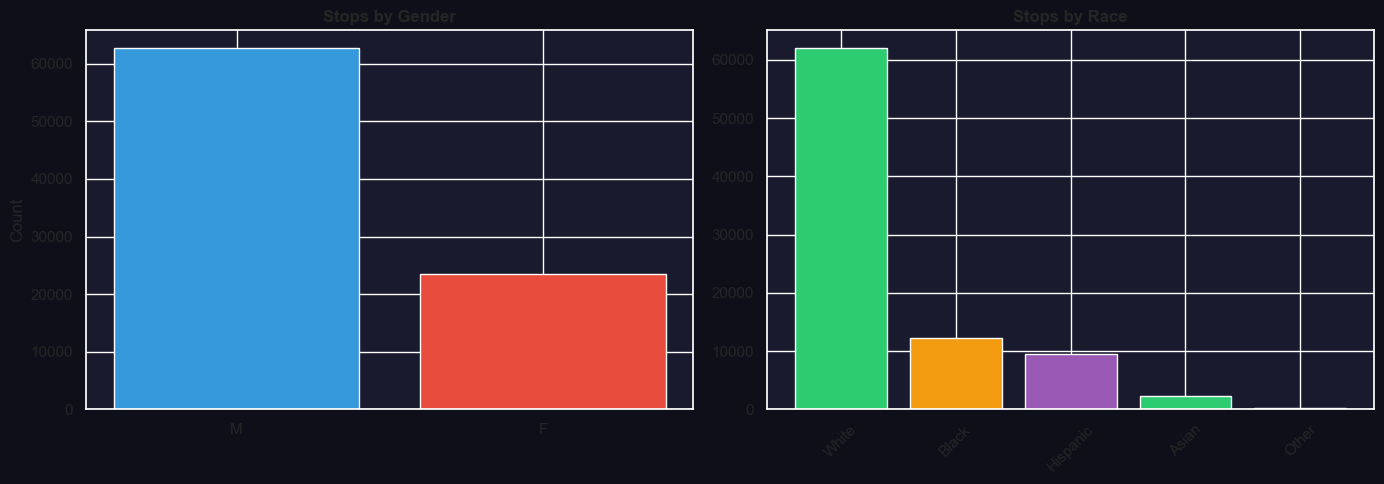

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gender_counts = df_clean['driver_gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Stops by Gender', fontweight='bold')
axes[0].set_ylabel('Count')
race_counts = df_clean['driver_race'].value_counts()
axes[1].bar(range(len(race_counts)), race_counts.values, color=['#2ecc71', '#f39c12', '#9b59b6'])
axes[1].set_xticks(range(len(race_counts)))
axes[1].set_xticklabels(race_counts.index, rotation=45)
axes[1].set_title('Stops by Race', fontweight='bold')
plt.tight_layout()
plt.show()

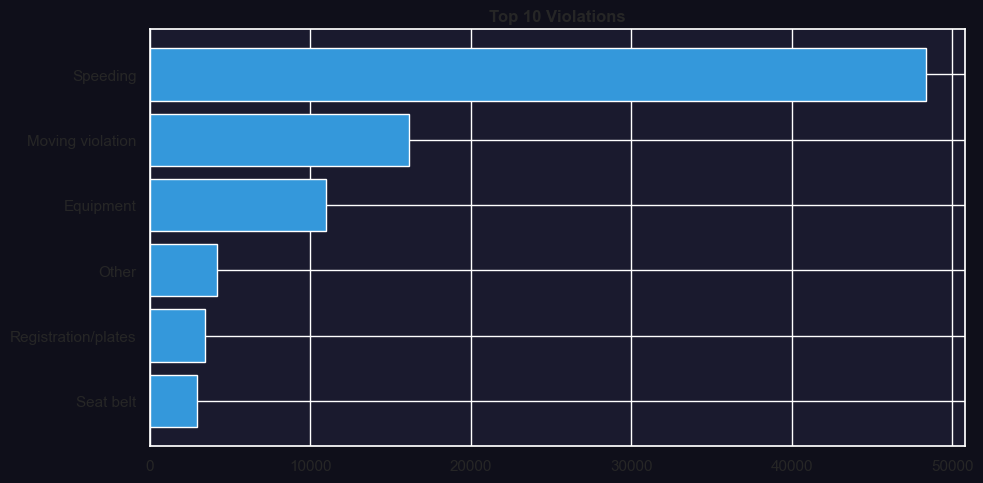

In [53]:
top_violations = df_clean['violation'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_violations)), top_violations.values, color='#3498db')
ax.set_yticks(range(len(top_violations)))
ax.set_yticklabels(top_violations.index)
ax.set_title('Top 10 Violations', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

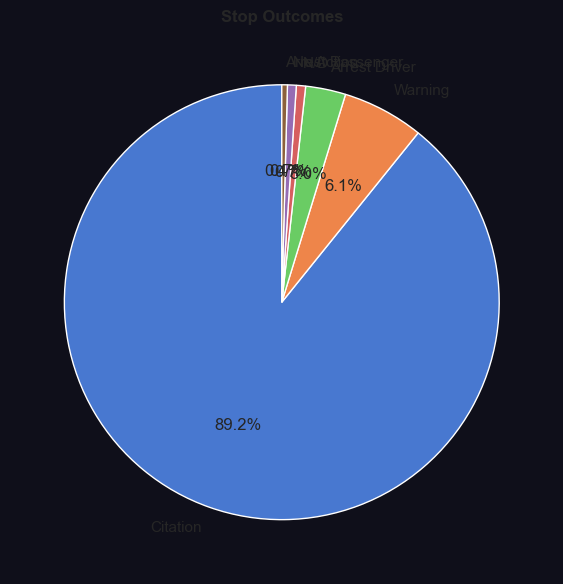

In [54]:
outcomes = df_clean['stop_outcome'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(outcomes.values, labels=outcomes.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Stop Outcomes', fontweight='bold')
plt.tight_layout()
plt.show()

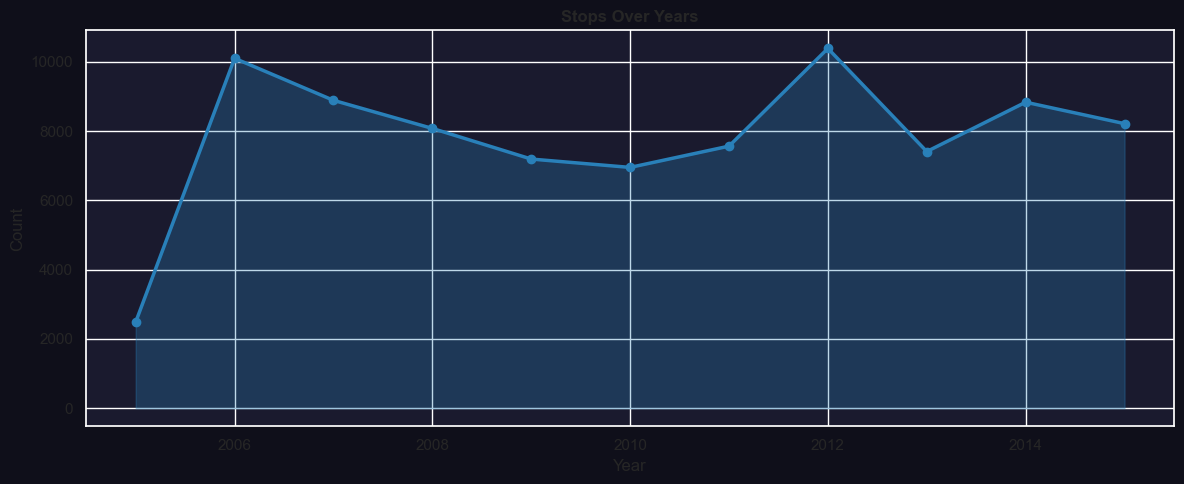

In [55]:
stops_by_year = df_clean['year'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(stops_by_year.index, stops_by_year.values, marker='o', linewidth=2.5, color='#2980b9')
plt.fill_between(stops_by_year.index, stops_by_year.values, alpha=0.3, color='#2980b9')
plt.title('Stops Over Years', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

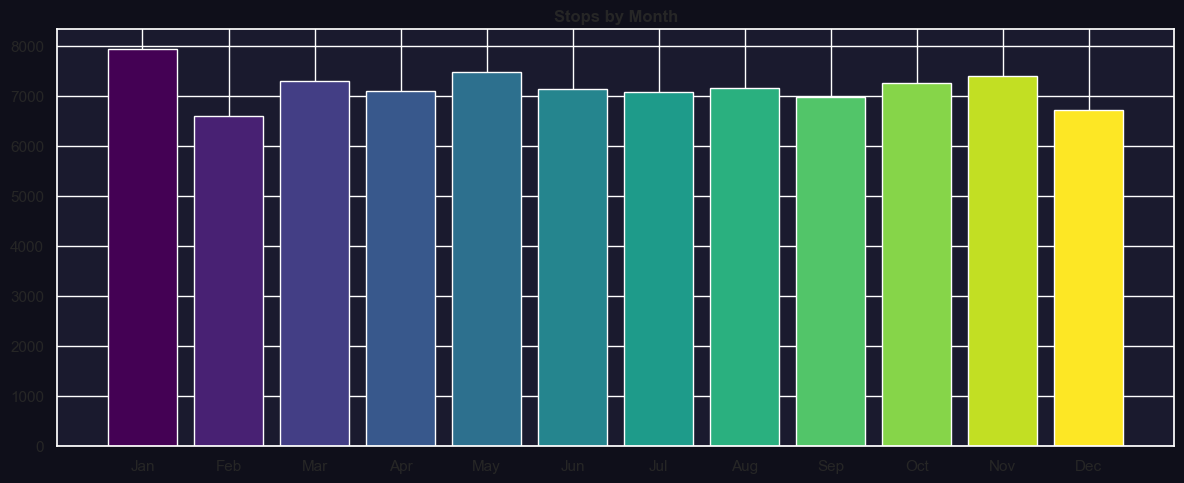

In [56]:
stops_by_month = df_clean['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(12, 5))
plt.bar(range(len(stops_by_month)), stops_by_month.values, color=plt.cm.viridis(np.linspace(0, 1, 12)))
plt.xticks(range(len(stops_by_month)), [month_names[m-1] for m in stops_by_month.index])
plt.title('Stops by Month', fontweight='bold')
plt.tight_layout()
plt.show()

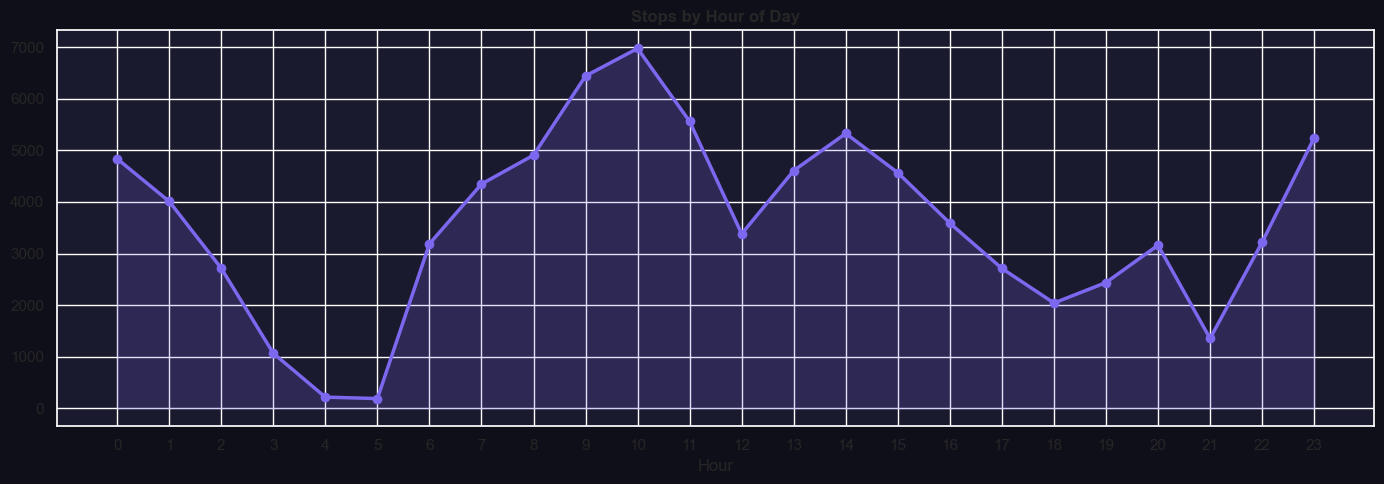

In [57]:
hourly = df_clean.groupby('hour').size().reset_index(name='stops')
plt.figure(figsize=(14, 5))
plt.plot(hourly['hour'], hourly['stops'], color='#7b68ee', linewidth=2.5, marker='o')
plt.fill_between(hourly['hour'], hourly['stops'], alpha=0.2, color='#7b68ee')
plt.title('Stops by Hour of Day', fontweight='bold')
plt.xlabel('Hour')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

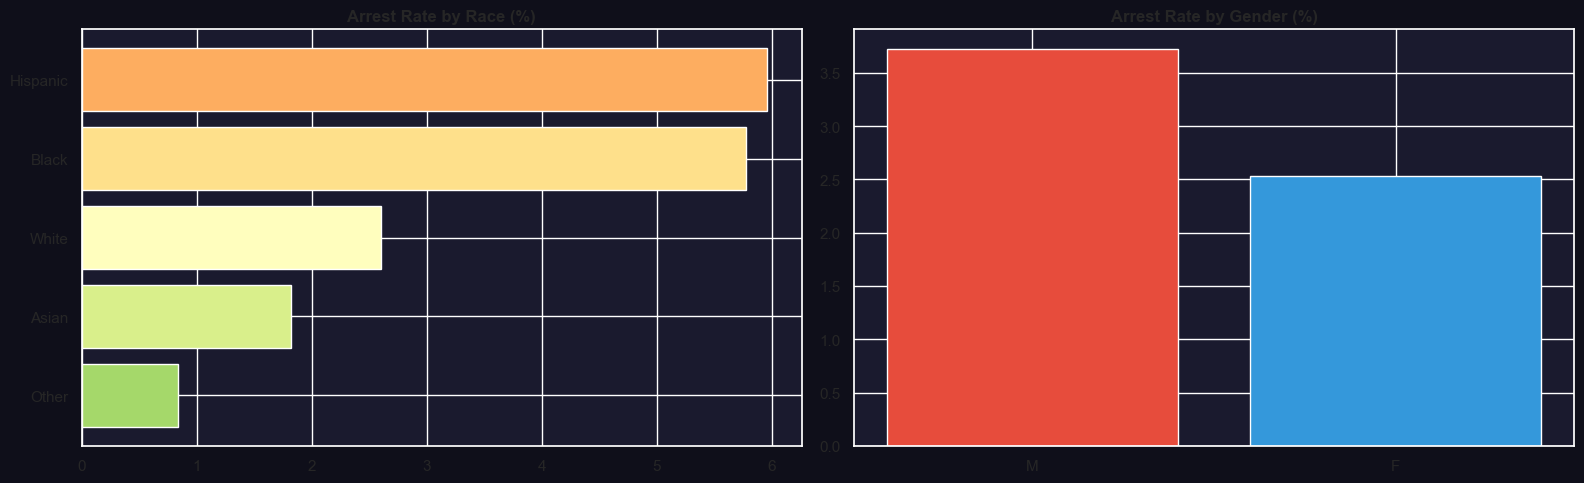

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
arrest_race_sorted = arrest_race.sort_values('rate_%', ascending=True)
axes[0].barh(range(len(arrest_race_sorted)), arrest_race_sorted['rate_%'], color=plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(arrest_race_sorted))))
axes[0].set_yticks(range(len(arrest_race_sorted)))
axes[0].set_yticklabels(arrest_race_sorted.index)
axes[0].set_title('Arrest Rate by Race (%)', fontweight='bold')
arrest_gender_sorted = arrest_gender.sort_values('rate_%', ascending=False)
axes[1].bar(range(len(arrest_gender_sorted)), arrest_gender_sorted['rate_%'], color=['#e74c3c', '#3498db'])
axes[1].set_xticks(range(len(arrest_gender_sorted)))
axes[1].set_xticklabels(arrest_gender_sorted.index)
axes[1].set_title('Arrest Rate by Gender (%)', fontweight='bold')
plt.tight_layout()
plt.show()

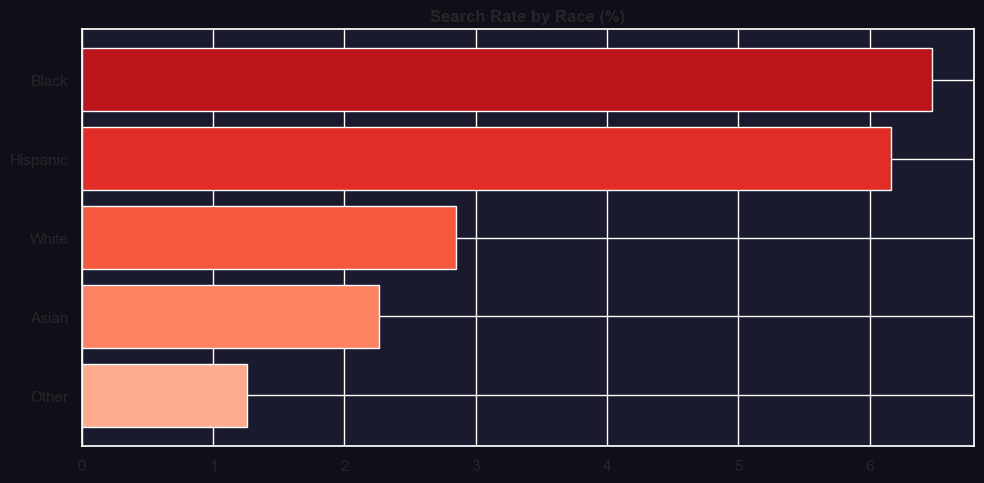

In [59]:
search_race = df_clean.groupby('driver_race')['search_conducted'].agg(['sum', 'count'])
search_race['rate_%'] = (search_race['sum'] / search_race['count'] * 100).astype(float).round(2)
search_race_sorted = search_race.sort_values('rate_%', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(search_race_sorted)), search_race_sorted['rate_%'], color=plt.cm.Reds(np.linspace(0.3, 0.8, len(search_race_sorted))))
ax.set_yticks(range(len(search_race_sorted)))
ax.set_yticklabels(search_race_sorted.index)
ax.set_title('Search Rate by Race (%)', fontweight='bold')
plt.tight_layout()
plt.show()

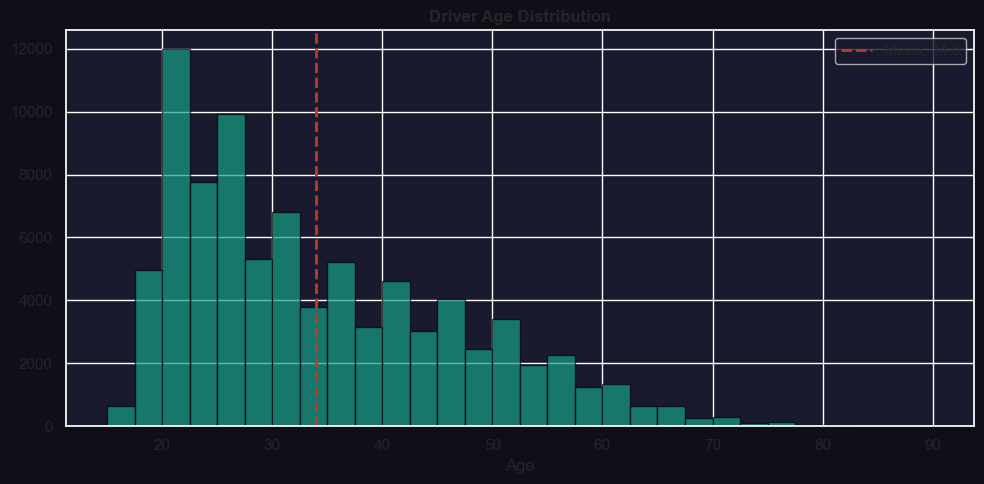

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean['driver_age'], bins=30, color='#16a085', alpha=0.7, edgecolor='black')
plt.axvline(df_clean['driver_age'].mean(), color='#c0392b', linestyle='--', linewidth=2, label=f"Mean: {df_clean['driver_age'].mean():.1f}")
plt.title('Driver Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()

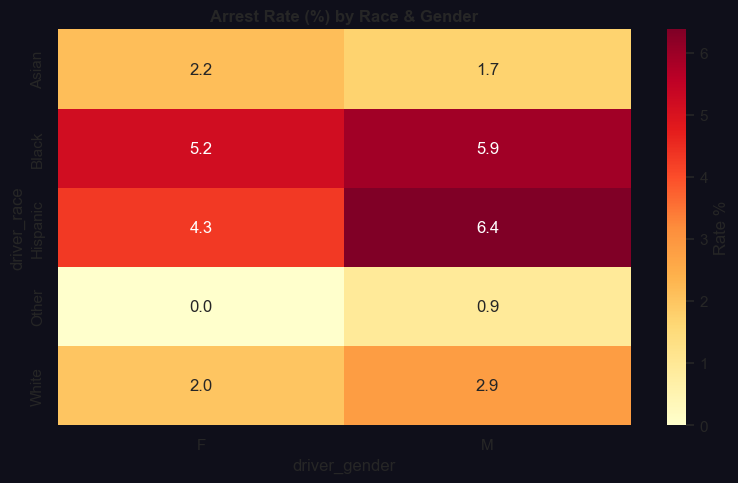

In [61]:
arrest_pivot = df_clean.groupby(['driver_race', 'driver_gender'])['is_arrested'].mean().unstack() * 100
arrest_pivot = arrest_pivot.astype(float)
plt.figure(figsize=(8, 5))
sns.heatmap(arrest_pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Rate %'})
plt.title('Arrest Rate (%) by Race & Gender', fontweight='bold')
plt.tight_layout()
plt.show()

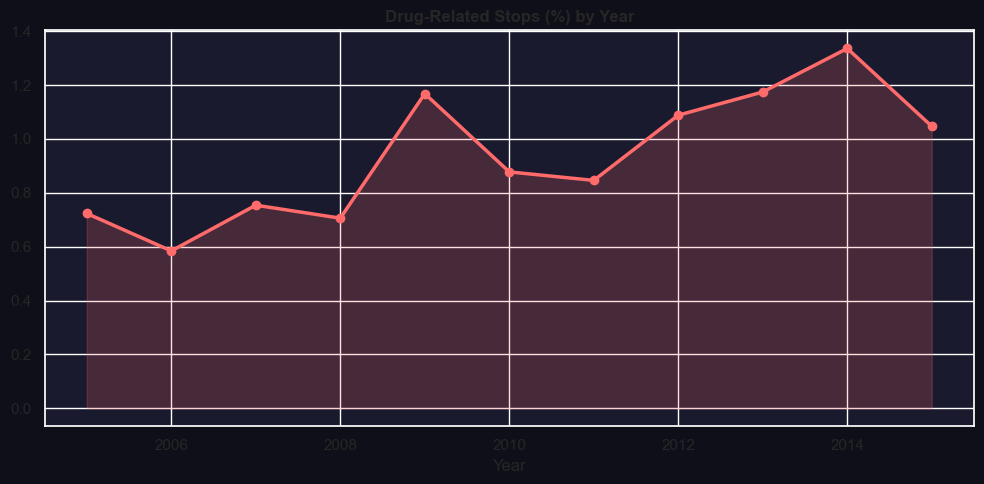

In [62]:
drug_yearly = df_clean.groupby('year')['drugs_related_stop'].mean() * 100
drug_yearly = drug_yearly.astype(float)
plt.figure(figsize=(10, 5))
plt.plot(drug_yearly.index, drug_yearly.values, color='#ff6b6b', linewidth=2.5, marker='o')
plt.fill_between(drug_yearly.index, drug_yearly.values, alpha=0.2, color='#ff6b6b')
plt.title('Drug-Related Stops (%) by Year', fontweight='bold')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## 6. Key Insights

**Main Findings:**

1. Demographic disparities in arrest & search rates
2. Speeding dominates violations (~60%)
3. Summer months peak in stop volume
4. Afternoon peak (2-5 PM) in hourly stops
5. 75% of stops under 15 minutes

**Recommendations:**

- Optimize patrol scheduling around peaks
- Investigate demographic disparities
- Focus speed enforcement on peak times
- Review long stops for improvements
- Expand data collection for geographic analysis